# Capstone local notebook

This notebook demonstrates the minimal local workflow: activate the `.venv311` Python 3.11 environment, open Jupyter from that environment, and run the cells below to load and inspect `df_power.csv`.

## Quick setup (run in a terminal)

1. Activate venv: `source .venv311/bin/activate`
2. Install deps (if needed): `pip install -r requirements.txt`
3. Start Jupyter from the same environment: `jupyter lab` or `jupyter notebook`

In [1]:
import sys, platform
import pathlib
import importlib
print('Python executable:', sys.executable)
print('Python version:', sys.version.split()[0])
print('Platform:', platform.platform())

def check(module_name):
    try:
        m = importlib.import_module(module_name)
        print(module_name, 'version =>', getattr(m, '__version__', 'unknown'))
    except Exception as e:
        print(module_name, 'NOT available:', e)

check('pandas')
check('pybaseball')

Python executable: /opt/homebrew/opt/python@3.11/bin/python3.11
Python version: 3.11.14
Platform: macOS-26.3.1-arm64-arm-64bit
pandas version => 3.0.2
pybaseball version => 2.2.7


In [2]:
import pandas as pd
from pathlib import Path
p = Path('df_power.csv').resolve()
print('CSV path:', p)
df = pd.read_csv(p, low_memory=False)
print('Shape:', df.shape)
display(df[['Season','Name','HR']].head())

CSV path: /Users/sashabates/Desktop/4320/df_power.csv
Shape: (6515, 6)


,Season,Name,HR
0,2016,A.J. Cole,0
1,2017,A.J. Cole,0
2,2018,A.J. Cole,1
3,2019,A.J. Cole,0
4,2020,A.J. Cole,0


In [3]:
from pybaseball import batting_stats_bref

dfs = []
for year in range(2016, 2026):
    df_year = batting_stats_bref(year)
    df_year['Season'] = year
    dfs.append(df_year)

df_full = pd.concat(dfs, ignore_index=True)
print(df_full.shape)

(8244, 29)


In [4]:
# Drop SLG if it already exists to avoid duplicates
if 'SLG' in df.columns:
    df = df.drop(columns=['SLG'])

df = df.merge(
    df_full[['Name', 'Season', 'SLG']],
    on=['Name', 'Season'],
    how='left'
)
df = df.dropna(subset=['SLG'])
print(df.shape)
print(df.columns.tolist())

(5460, 7)
['IDfg', 'Season', 'Name', 'Age', 'AB', 'HR', 'SLG']


In [5]:
# Create lagged HR feature (previous season's HR)
df = df.sort_values(['Name', 'Season'])
df['HR_prev']  = df.groupby('Name')['HR'].shift(1)
df['AB_prev']  = df.groupby('Name')['AB'].shift(1)
df['SLG_prev'] = df.groupby('Name')['SLG'].shift(1)

# Drop rows with no previous season
df = df.dropna(subset=['HR_prev', 'AB_prev', 'SLG_prev'])

print(f"Dataset shape after adding lagged features: {df.shape}")
print(df[['Season', 'Name', 'Age', 'AB', 'HR', 'HR_prev', 'AB_prev', 'SLG_prev']].head(10))

Dataset shape after adding lagged features: (4220, 10)
    Season           Name  Age   AB  HR  HR_prev  AB_prev  SLG_prev
1     2017      A.J. Cole   25   14   0      0.0      7.0     0.000
2     2018      A.J. Cole   26    3   1      0.0     14.0     0.143
7     2017     A.J. Ellis   36  143   6      2.0    171.0     0.298
8     2018     A.J. Ellis   37  151   1      6.0    143.0     0.371
23    2017  Aaron Altherr   26  372  19      4.0    198.0     0.288
24    2018  Aaron Altherr   27  243   8     19.0    372.0     0.516
25    2019  Aaron Altherr   28   61   1      8.0    243.0     0.333
27    2017    Aaron Hicks   27  301  15      8.0    327.0     0.336
28    2018    Aaron Hicks   28  480  27     15.0    301.0     0.475
29    2019    Aaron Hicks   29  221  12     27.0    480.0     0.467


In [6]:
train_mask = df['Season'] < 2024
val_mask = df['Season'] == 2024
test_mask = df['Season'] == 2025

print(f"Train: {train_mask.sum()} rows")
print(f"Val: {val_mask.sum()} rows")
print(f"Test: {test_mask.sum()} rows")

Train: 3260 rows
Val: 477 rows
Test: 483 rows


In [7]:
# Binarize target: power hitter = 20+ HR in a season
df['power_hitter'] = (df['HR'] >= 20).astype(int)

print(f"Power hitters in train: {df.loc[train_mask, 'power_hitter'].sum()} / {train_mask.sum()}")
print(f"Power hitters in val:   {df.loc[val_mask, 'power_hitter'].sum()} / {val_mask.sum()}")
print(f"Power hitters in test:  {df.loc[test_mask, 'power_hitter'].sum()} / {test_mask.sum()}")

Power hitters in train: 538 / 3260
Power hitters in val:   81 / 477
Power hitters in test:  84 / 483


In [8]:
df['elite_hitter'] = (df['HR'] >= 40).astype(int)

y_train_elite = df.loc[train_mask, 'elite_hitter']
y_val_elite   = df.loc[val_mask,   'elite_hitter']
y_test_elite  = df.loc[test_mask,  'elite_hitter']

## Preprocessing and Splitting

Prepare data for linear regression: select features, split, scale.

In [9]:
import numpy as np
from sklearn.preprocessing import StandardScaler

# Select features and target
features = ['Age', 'AB_prev', 'HR_prev', 'SLG_prev']
target = 'HR'

# Temporal split: 8/1/1 by season
train_mask = df['Season'] < 2024
val_mask = df['Season'] == 2024
test_mask = df['Season'] == 2025

X_train = df.loc[train_mask, features]
y_train = df.loc[train_mask, 'power_hitter']

X_val = df.loc[val_mask, features]
y_val = df.loc[val_mask, 'power_hitter']

X_test = df.loc[test_mask, features]
y_test = df.loc[test_mask, 'power_hitter']

# Scale features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

print(f"Train: {X_train.shape}, Val: {X_val.shape}, Test: {X_test.shape}")

Train: (3260, 4), Val: (477, 4), Test: (483, 4)


In [10]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix

clf = LogisticRegression()
clf.fit(X_train_scaled, y_train)

y_pred_clf = clf.predict(X_val_scaled)

print(confusion_matrix(y_val, y_pred_clf))
print()
print(classification_report(y_val, y_pred_clf))

[[386  10]
 [ 59  22]]

              precision    recall  f1-score   support

           0       0.87      0.97      0.92       396
           1       0.69      0.27      0.39        81

    accuracy                           0.86       477
   macro avg       0.78      0.62      0.65       477
weighted avg       0.84      0.86      0.83       477



In [11]:
from sklearn.naive_bayes import GaussianNB

# Naive Bayes (Gaussian variant for continuous features)
gnb = GaussianNB()
gnb.fit(X_train_scaled, y_train)

y_pred_gnb = gnb.predict(X_val_scaled)

print("Gaussian Naive Bayes:")
print(confusion_matrix(y_val, y_pred_gnb))
print()
print(classification_report(y_val, y_pred_gnb))

Gaussian Naive Bayes:
[[340  56]
 [ 28  53]]

              precision    recall  f1-score   support

           0       0.92      0.86      0.89       396
           1       0.49      0.65      0.56        81

    accuracy                           0.82       477
   macro avg       0.71      0.76      0.72       477
weighted avg       0.85      0.82      0.83       477



In [12]:
from sklearn.neighbors import KNeighborsClassifier

# Try k = 3, 5, 11
for k in [3, 5, 11]:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train_scaled, y_train)
    y_pred_knn = knn.predict(X_val_scaled)
    report = classification_report(y_val, y_pred_knn, output_dict=True)
    print(f"k={k} | F1 (power hitter): {report['1']['f1-score']:.2f} | Accuracy: {report['accuracy']:.2f}")

k=3 | F1 (power hitter): 0.40 | Accuracy: 0.81
k=5 | F1 (power hitter): 0.39 | Accuracy: 0.82
k=11 | F1 (power hitter): 0.38 | Accuracy: 0.84


In [13]:
knn_best = KNeighborsClassifier(n_neighbors=11)
knn_best.fit(X_train_scaled, y_train)
y_pred_knn_best = knn_best.predict(X_val_scaled)

print("kNN (k=11):")
print(confusion_matrix(y_val, y_pred_knn_best))
print()
print(classification_report(y_val, y_pred_knn_best))


kNN (k=11):
[[375  21]
 [ 57  24]]

              precision    recall  f1-score   support

           0       0.87      0.95      0.91       396
           1       0.53      0.30      0.38        81

    accuracy                           0.84       477
   macro avg       0.70      0.62      0.64       477
weighted avg       0.81      0.84      0.82       477



In [14]:
from sklearn.svm import LinearSVC

# Linear SVM - try 3 values of C
for C in [0.01, 0.1, 1.0]:
    svm_linear = LinearSVC(C=C, max_iter=2000)
    svm_linear.fit(X_train_scaled, y_train)
    y_pred_svm = svm_linear.predict(X_val_scaled)
    report = classification_report(y_val, y_pred_svm, output_dict=True)
    print(f"C={C} | F1 (power hitter): {report['1']['f1-score']:.2f} | Accuracy: {report['accuracy']:.2f}")

C=0.01 | F1 (power hitter): 0.32 | Accuracy: 0.85
C=0.1 | F1 (power hitter): 0.32 | Accuracy: 0.85
C=1.0 | F1 (power hitter): 0.32 | Accuracy: 0.85


In [15]:
from sklearn.svm import SVC

# RBF SVM - try combinations of C and gamma
for C in [0.1, 1.0]:
    for gamma in ['scale', 0.1]:
        svm_rbf = SVC(kernel='rbf', C=C, gamma=gamma)
        svm_rbf.fit(X_train_scaled, y_train)
        y_pred_rbf = svm_rbf.predict(X_val_scaled)
        report = classification_report(y_val, y_pred_rbf, output_dict=True)
        print(f"C={C}, gamma={gamma} | F1: {report['1']['f1-score']:.2f} | Accuracy: {report['accuracy']:.2f}")
        

C=0.1, gamma=scale | F1: 0.21 | Accuracy: 0.84
C=0.1, gamma=0.1 | F1: 0.05 | Accuracy: 0.83
C=1.0, gamma=scale | F1: 0.29 | Accuracy: 0.85
C=1.0, gamma=0.1 | F1: 0.21 | Accuracy: 0.84


In [16]:
# Best RBF SVM - full evaluation
svm_best = SVC(kernel='rbf', C=1.0, gamma='scale')
svm_best.fit(X_train_scaled, y_train)
y_pred_best = svm_best.predict(X_val_scaled)

print("Best RBF SVM (C=1.0, gamma=scale):")
print(confusion_matrix(y_val, y_pred_best))
print()
print(classification_report(y_val, y_pred_best))

Best RBF SVM (C=1.0, gamma=scale):
[[389   7]
 [ 66  15]]

              precision    recall  f1-score   support

           0       0.85      0.98      0.91       396
           1       0.68      0.19      0.29        81

    accuracy                           0.85       477
   macro avg       0.77      0.58      0.60       477
weighted avg       0.83      0.85      0.81       477



In [17]:
from sklearn.tree import DecisionTreeClassifier

# Decision tree - try a few max depths
for depth in [3, 5, None]:
    dt = DecisionTreeClassifier(max_depth=depth, random_state=4320)
    dt.fit(X_train_scaled, y_train)
    y_pred_dt = dt.predict(X_val_scaled)
    report = classification_report(y_val, y_pred_dt, output_dict=True)
    print(f"max_depth={depth} | F1: {report['1']['f1-score']:.2f} | Accuracy: {report['accuracy']:.2f}")

max_depth=3 | F1: 0.45 | Accuracy: 0.87
max_depth=5 | F1: 0.43 | Accuracy: 0.85
max_depth=None | F1: 0.43 | Accuracy: 0.79


In [18]:
from sklearn.ensemble import RandomForestClassifier

for n_trees in [50, 100, 200]:
    rf = RandomForestClassifier(n_estimators=n_trees, random_state=4320)
    rf.fit(X_train_scaled, y_train)
    y_pred_rf = rf.predict(X_val_scaled)
    report = classification_report(y_val, y_pred_rf, output_dict=True)
    print(f"n_trees={n_trees} | F1: {report['1']['f1-score']:.2f} | Accuracy: {report['accuracy']:.2f}")

n_trees=50 | F1: 0.42 | Accuracy: 0.83
n_trees=100 | F1: 0.42 | Accuracy: 0.83
n_trees=200 | F1: 0.43 | Accuracy: 0.84


In [19]:
from sklearn.ensemble import GradientBoostingClassifier

for lr in [0.05, 0.1, 0.2]:
    gb = GradientBoostingClassifier(learning_rate=lr, n_estimators=100, random_state=4320)
    gb.fit(X_train_scaled, y_train)
    y_pred_gb = gb.predict(X_val_scaled)
    report = classification_report(y_val, y_pred_gb, output_dict=True)
    print(f"lr={lr} | F1: {report['1']['f1-score']:.2f} | Accuracy: {report['accuracy']:.2f}")

lr=0.05 | F1: 0.43 | Accuracy: 0.85
lr=0.1 | F1: 0.44 | Accuracy: 0.85
lr=0.2 | F1: 0.45 | Accuracy: 0.85


In [20]:
# Final test evaluation - Gradient Boosting (lr=0.05)
gb_final = GradientBoostingClassifier(learning_rate=0.05, n_estimators=100, random_state=4320)
gb_final.fit(X_train_scaled, y_train)
y_pred_final = gb_final.predict(X_test_scaled)

print("Final Test Evaluation - Gradient Boosting (lr=0.05):")
print(confusion_matrix(y_test, y_pred_final))
print()
print(classification_report(y_test, y_pred_final))

Final Test Evaluation - Gradient Boosting (lr=0.05):
[[386  13]
 [ 61  23]]

              precision    recall  f1-score   support

           0       0.86      0.97      0.91       399
           1       0.64      0.27      0.38        84

    accuracy                           0.85       483
   macro avg       0.75      0.62      0.65       483
weighted avg       0.82      0.85      0.82       483



In [21]:
gb_elite = GradientBoostingClassifier(learning_rate=0.05, n_estimators=100, random_state=4320)
gb_elite.fit(X_train_scaled, y_train_elite)

print("Elite (40+ HR) - Test Report:")
print(classification_report(y_test_elite, gb_elite.predict(X_test_scaled)))

Elite (40+ HR) - Test Report:
              precision    recall  f1-score   support

           0       0.99      1.00      0.99       477
           1       0.00      0.00      0.00         6

    accuracy                           0.99       483
   macro avg       0.49      0.50      0.50       483
weighted avg       0.98      0.99      0.98       483



## Linear Regression Model

Define predict and loss functions.

In [22]:
# Linear regression: y = Xw + b
def predict(X, w, b):
    return X @ w + b

# MSE loss
def compute_loss(y_true, y_pred):
    return np.mean((y_pred - y_true) ** 2)

# Initialize parameters
n_features = X_train_scaled.shape[1]
w = np.zeros(n_features)
b = 0.0

print(f"Initialized w: {w}, b: {b}")
y_pred_init = predict(X_train_scaled, w, b)
loss_init = compute_loss(y_train, y_pred_init)
print(f"Initial loss: {loss_init:.4f}")

Initialized w: [0. 0. 0. 0.], b: 0.0
Initial loss: 0.1650


## Training with Gradient Descent

Train for 100 epochs, track losses.

In [23]:
# Training
learning_rate = 0.02
epochs = 100

w = np.zeros(X_train_scaled.shape[1])
b = 0.0

train_losses = []
val_losses = []

for epoch in range(epochs):
    y_pred_train = predict(X_train_scaled, w, b)
    error = y_pred_train - y_train
    grad_w = (2 / len(y_train)) * (X_train_scaled.T @ error)
    grad_b = (2 / len(y_train)) * np.sum(error)
    
    w -= learning_rate * grad_w
    b -= learning_rate * grad_b
    
    train_loss = compute_loss(y_train, y_pred_train)
    train_losses.append(train_loss)
    
    y_pred_val = predict(X_val_scaled, w, b)
    val_loss = compute_loss(y_val, y_pred_val)
    val_losses.append(val_loss)
    
    if (epoch + 1) % 20 == 0:
        print(f"Epoch {epoch+1}: Train {train_loss:.4f}, Val {val_loss:.4f}")

print(f"Final: Train {train_losses[-1]:.4f}, Val {val_losses[-1]:.4f}")
w_final, b_final = w, b

Epoch 20: Train 0.1191, Val 0.1161
Epoch 40: Train 0.1126, Val 0.1103
Epoch 60: Train 0.1111, Val 0.1093
Epoch 80: Train 0.1106, Val 0.1090
Epoch 100: Train 0.1103, Val 0.1087
Final: Train 0.1103, Val 0.1087


## Visualize Training Progress

Plot loss curves.

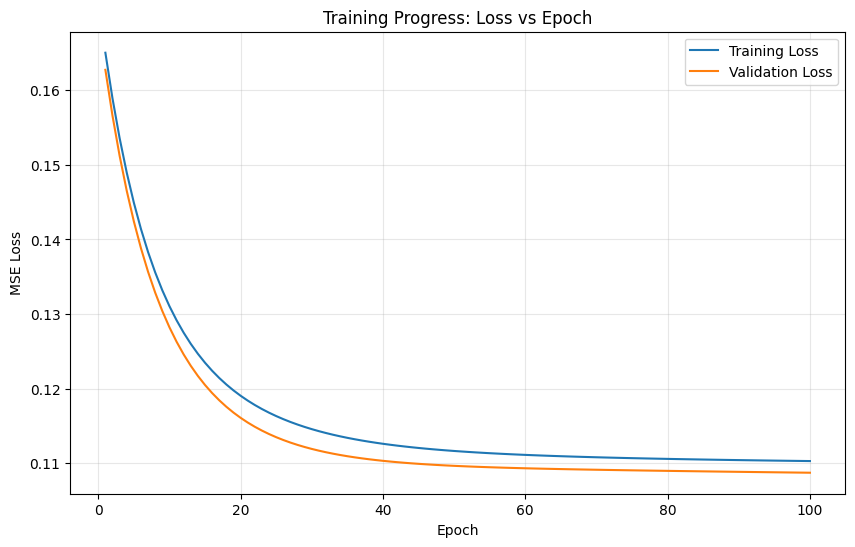

In [24]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.plot(range(1, len(train_losses) + 1), train_losses, label='Training Loss')
plt.plot(range(1, len(val_losses) + 1), val_losses, label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('MSE Loss')
plt.title('Training Progress: Loss vs Epoch')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [25]:
# Drop rows with missing SLG for clustering
df_cluster = df.dropna(subset=['SLG'])
print(f"Rows available for clustering: {df_cluster.shape[0]}")

Rows available for clustering: 4220


In [26]:
from sklearn.preprocessing import StandardScaler

# Features for clustering
cluster_features = ['Age', 'AB', 'HR', 'SLG']

X_cluster = df_cluster[cluster_features].copy()

scaler_cluster = StandardScaler()
X_cluster_scaled = scaler_cluster.fit_transform(X_cluster)

print(f"Clustering matrix shape: {X_cluster_scaled.shape}")

Clustering matrix shape: (4220, 4)


Explained variance ratio: [0.56185332 0.24889394 0.14532812 0.04392462]
Cumulative: [0.56185332 0.81074727 0.95607538 1.        ]


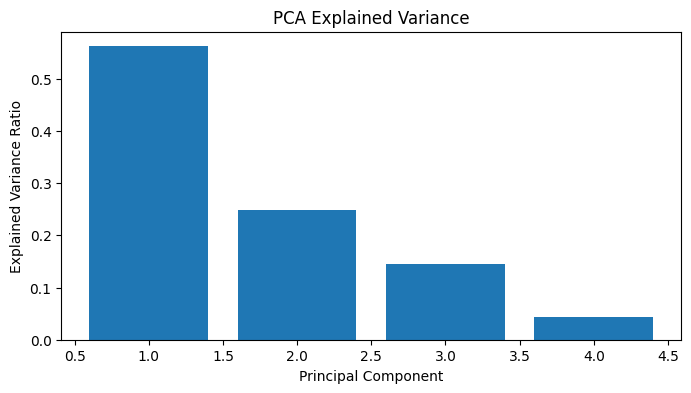

In [27]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

# PCA
pca = PCA()
X_pca = pca.fit_transform(X_cluster_scaled)

# Explained variance
print("Explained variance ratio:", pca.explained_variance_ratio_)
print("Cumulative:", pca.explained_variance_ratio_.cumsum())

# Plot
plt.figure(figsize=(8, 4))
plt.bar(range(1, 5), pca.explained_variance_ratio_)
plt.xlabel('Principal Component')
plt.ylabel('Explained Variance Ratio')
plt.title('PCA Explained Variance')
plt.show()

In [28]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

inertias = []
silhouettes = []
k_values = [2, 3, 4, 5, 6, 8]

for k in k_values:
    km = KMeans(n_clusters=k, random_state=4320, n_init=10)
    labels = km.fit_predict(X_cluster_scaled)
    inertias.append(km.inertia_)
    silhouettes.append(silhouette_score(X_cluster_scaled, labels))
    print(f"k={k} | Inertia: {km.inertia_:.1f} | Silhouette: {silhouette_score(X_cluster_scaled, labels):.3f}")

k=2 | Inertia: 10359.0 | Silhouette: 0.356
k=3 | Inertia: 8402.0 | Silhouette: 0.300
k=4 | Inertia: 6807.0 | Silhouette: 0.290
k=5 | Inertia: 5976.4 | Silhouette: 0.266
k=6 | Inertia: 5322.4 | Silhouette: 0.265
k=8 | Inertia: 4271.2 | Silhouette: 0.266


In [29]:
# Final k-means with k=2
km_final = KMeans(n_clusters=2, random_state=4320, n_init=10)
df_cluster['cluster'] = km_final.fit_predict(X_cluster_scaled)

# Cluster means
print(df_cluster.groupby('cluster')[cluster_features].mean().round(2))

# How many in each cluster
print("\nCluster sizes:")
print(df_cluster['cluster'].value_counts())

           Age      AB     HR   SLG
cluster                            
0        28.66  132.00   3.11  0.32
1        28.32  453.49  19.13  0.46

Cluster sizes:
cluster
0    2537
1    1683
Name: count, dtype: int64


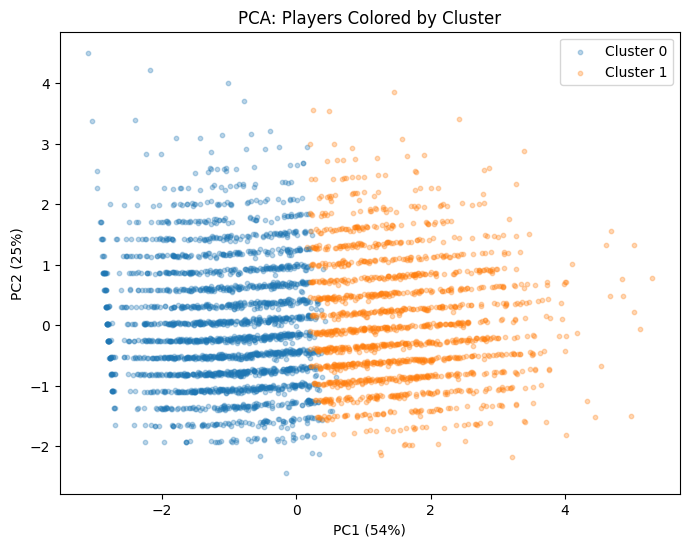

In [30]:
plt.figure(figsize=(8, 6))
for cluster in [0, 1]:
    mask = df_cluster['cluster'] == cluster
    plt.scatter(X_pca[mask, 0], X_pca[mask, 1], 
                alpha=0.3, s=10, label=f'Cluster {cluster}')
plt.xlabel('PC1 (54%)')
plt.ylabel('PC2 (25%)')
plt.title('PCA: Players Colored by Cluster')
plt.legend()
plt.show()

In [31]:
from sklearn.metrics import adjusted_rand_score

df_cluster['power_hitter'] = (df_cluster['HR'] >= 20).astype(int)

ari = adjusted_rand_score(df_cluster['power_hitter'], df_cluster['cluster'])
print(f"Adjusted Rand Index: {ari:.3f}")

print(pd.crosstab(df_cluster['cluster'], df_cluster['power_hitter'], 
                  rownames=['Cluster'], colnames=['Power Hitter']))

Adjusted Rand Index: 0.273
Power Hitter     0    1
Cluster                
0             2537    0
1              980  703


In [32]:
import torch
print(torch.__version__)

2.11.0


In [33]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader

# Convert data to tensors
X_train_t = torch.tensor(X_train_scaled, dtype=torch.float32)
y_train_t = torch.tensor(y_train.values, dtype=torch.float32)
X_val_t = torch.tensor(X_val_scaled, dtype=torch.float32)
y_val_t = torch.tensor(y_val.values, dtype=torch.float32)

print(f"Train tensor: {X_train_t.shape}")
print(f"Val tensor: {X_val_t.shape}")

Train tensor: torch.Size([3260, 4])
Val tensor: torch.Size([477, 4])


In [34]:
# Small MLP: 2 hidden layers
class MLP(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(4, 16),
            nn.ReLU(),
            nn.Linear(16, 8),
            nn.ReLU(),
            nn.Linear(8, 1),
            nn.Sigmoid()
        )
    
    def forward(self, x):
        return self.net(x).squeeze()

model = MLP()
print(model)

MLP(
  (net): Sequential(
    (0): Linear(in_features=4, out_features=16, bias=True)
    (1): ReLU()
    (2): Linear(in_features=16, out_features=8, bias=True)
    (3): ReLU()
    (4): Linear(in_features=8, out_features=1, bias=True)
    (5): Sigmoid()
  )
)


In [35]:
# Training
criterion = nn.BCELoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

train_losses = []
val_losses = []
epochs = 100

for epoch in range(epochs):
    model.train()
    optimizer.zero_grad()
    y_pred = model(X_train_t)
    loss = criterion(y_pred, y_train_t)
    loss.backward()
    optimizer.step()
    train_losses.append(loss.item())
    
    model.eval()
    with torch.no_grad():
        val_pred = model(X_val_t)
        val_loss = criterion(val_pred, y_val_t)
        val_losses.append(val_loss.item())
    
    if (epoch + 1) % 20 == 0:
        print(f"Epoch {epoch+1}: Train {loss.item():.4f}, Val {val_loss.item():.4f}")

print("Done")

Epoch 20: Train 0.5581, Val 0.5642
Epoch 40: Train 0.5074, Val 0.5178
Epoch 60: Train 0.4608, Val 0.4747
Epoch 80: Train 0.4227, Val 0.4386
Epoch 100: Train 0.3964, Val 0.4128
Done


In [36]:
import random

# Reproducibility
torch.manual_seed(4320)
random.seed(4320)
import numpy as np
np.random.seed(4320)

print("Random seeds set.")

Random seeds set.


In [37]:
# Reset with weighted loss to handle class imbalance
pos_weight = torch.tensor([396/81])  # ratio of negative to positive

model3 = MLP()
optimizer3 = optim.Adam(model3.parameters(), lr=0.001)
criterion_weighted = nn.BCEWithLogitsLoss(pos_weight=pos_weight)

# Rebuild model without sigmoid since BCEWithLogitsLoss handles it
class MLP2(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(4, 16),
            nn.ReLU(),
            nn.Linear(16, 8),
            nn.ReLU(),
            nn.Linear(8, 1)
        )
    def forward(self, x):
        return self.net(x).squeeze()

model3 = MLP2()
optimizer3 = optim.Adam(model3.parameters(), lr=0.001)
train_losses3 = []
val_losses3 = []

for epoch in range(200):
    model3.train()
    optimizer3.zero_grad()
    y_pred = model3(X_train_t)
    loss = criterion_weighted(y_pred, y_train_t)
    loss.backward()
    optimizer3.step()
    train_losses3.append(loss.item())
    
    model3.eval()
    with torch.no_grad():
        val_pred = model3(X_val_t)
        val_loss = criterion_weighted(val_pred, y_val_t)
        val_losses3.append(val_loss.item())
    
    if (epoch + 1) % 50 == 0:
        print(f"Epoch {epoch+1}: Train {loss.item():.4f}, Val {val_loss.item():.4f}")

model3.eval()
with torch.no_grad():
    val_pred3 = torch.sigmoid(model3(X_val_t))
    val_pred_labels3 = (val_pred3 >= 0.5).int().numpy()

print(classification_report(y_val, val_pred_labels3))

Epoch 50: Train 1.0702, Val 1.0696
Epoch 100: Train 0.9694, Val 0.9694
Epoch 150: Train 0.8896, Val 0.9058
Epoch 200: Train 0.8618, Val 0.8794
              precision    recall  f1-score   support

           0       0.94      0.70      0.80       396
           1       0.34      0.77      0.47        81

    accuracy                           0.71       477
   macro avg       0.64      0.73      0.64       477
weighted avg       0.83      0.71      0.74       477



In [38]:
# Save best checkpoint
torch.save(model3.state_dict(), 'best_mlp.pt')
print("Model saved.")

# Reload and verify
model_reload = MLP2()
model_reload.load_state_dict(torch.load('best_mlp.pt'))
model_reload.eval()

with torch.no_grad():
    val_pred_reload = torch.sigmoid(model_reload(X_val_t))
    val_pred_labels_reload = (val_pred_reload >= 0.7).int().numpy()

print(classification_report(y_val, val_pred_labels_reload))

Model saved.
              precision    recall  f1-score   support

           0       0.92      0.88      0.90       396
           1       0.51      0.62      0.56        81

    accuracy                           0.83       477
   macro avg       0.71      0.75      0.73       477
weighted avg       0.85      0.83      0.84       477



In [39]:
model3.eval()
with torch.no_grad():
    val_pred3 = torch.sigmoid(model3(X_val_t))

# Try different thresholds
for threshold in [0.3, 0.4, 0.5, 0.6, 0.7]:
    labels = (val_pred3 >= threshold).int().numpy()
    report = classification_report(y_val, labels, output_dict=True, zero_division=0)
    print(f"threshold={threshold} | F1: {report['1']['f1-score']:.2f} | Precision: {report['1']['precision']:.2f} | Recall: {report['1']['recall']:.2f}")

threshold=0.3 | F1: 0.40 | Precision: 0.26 | Recall: 0.89
threshold=0.4 | F1: 0.46 | Precision: 0.31 | Recall: 0.86
threshold=0.5 | F1: 0.47 | Precision: 0.34 | Recall: 0.77
threshold=0.6 | F1: 0.50 | Precision: 0.39 | Recall: 0.69
threshold=0.7 | F1: 0.56 | Precision: 0.51 | Recall: 0.62


In [40]:
with torch.no_grad():
    val_pred3 = torch.sigmoid(model3(X_val_t))
    val_pred_labels_final = (val_pred3 >= 0.7).int().numpy()

print(confusion_matrix(y_val, val_pred_labels_final))
print()
print(classification_report(y_val, val_pred_labels_final))

[[347  49]
 [ 31  50]]

              precision    recall  f1-score   support

           0       0.92      0.88      0.90       396
           1       0.51      0.62      0.56        81

    accuracy                           0.83       477
   macro avg       0.71      0.75      0.73       477
weighted avg       0.85      0.83      0.84       477



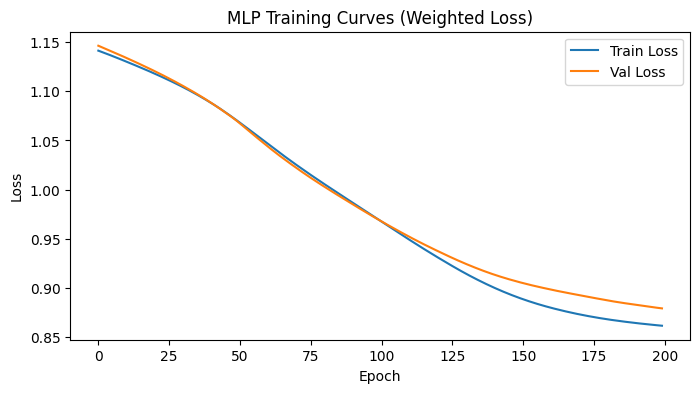

In [41]:
plt.figure(figsize=(8, 4))
plt.plot(train_losses3, label='Train Loss')
plt.plot(val_losses3, label='Val Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('MLP Training Curves (Weighted Loss)')
plt.legend()
plt.show()

In [42]:
gb_elite = GradientBoostingClassifier(learning_rate=0.05, n_estimators=100, random_state=4320)
gb_elite.fit(X_train_scaled, y_train_elite)

print("Elite (40+ HR) - Test Report:")
print(classification_report(y_test_elite, gb_elite.predict(X_test_scaled)))

Elite (40+ HR) - Test Report:
              precision    recall  f1-score   support

           0       0.99      1.00      0.99       477
           1       0.00      0.00      0.00         6

    accuracy                           0.99       483
   macro avg       0.49      0.50      0.50       483
weighted avg       0.98      0.99      0.98       483



In [48]:
from pybaseball import batting_stats_bref
import unicodedata

df_2025 = batting_stats_bref(2025)
df_2025 = df_2025[df_2025['AB'] >= 100].copy()
df_2025['Name'] = df_2025['Name'].str.encode('raw_unicode_escape').str.decode('utf-8', errors='replace')

df_2026 = pd.DataFrame({
    'Name':     df_2025['Name'],
    'Age':      df_2025['Age'] + 1,
    'AB_prev':  df_2025['AB'],
    'HR_prev':  df_2025['HR'],
    'SLG_prev': df_2025['SLG'],
}).dropna()

X_2026_scaled = scaler.transform(df_2026[['Age', 'AB_prev', 'HR_prev', 'SLG_prev']])

df_2026['power_prob'] = gb_final.predict_proba(X_2026_scaled)[:, 1]
df_2026['power_pred'] = (gb_final.predict_proba(X_2026_scaled)[:, 1] >= 0.35).astype(int)

predicted = (
    df_2026[df_2026['power_pred'] == 1]
    .sort_values('power_prob', ascending=False)
    .reset_index(drop=True)
)

print(f"Predicted 2026 Power Hitters ({len(predicted)} players):\n")
print(f"{'Name':<30} {'Age':>4}  {'HR_prev':>7}  {'SLG':>5}  {'Prob':>6}")
print("-" * 58)
for _, row in predicted.iterrows():
    print(f"{row['Name']:<30} {row['Age']:>4}  {row['HR_prev']:>7.0f}  {row['SLG_prev']:>5.3f}  {row['power_prob']:>6.3f}")

Predicted 2026 Power Hitters (86 players):

Name                            Age  HR_prev    SLG    Prob
----------------------------------------------------------
Eugenio Su\xc3\xa1rez            34       52  0.518   0.927
Cal Raleigh                      29       65  0.595   0.882
Shohei Ohtani                    31       63  0.629   0.831
Kyle Schwarber                   33       58  0.565   0.791
Jackson Chourio                  22       23  0.469   0.783
Riley Greene                     25       37  0.487   0.768
Julio Rodr\xc3\xadguez           25       36  0.476   0.710
Pete Crow-Armstrong              24       31  0.468   0.704
Tyler Soderstrom                 24       25  0.474   0.704
James Wood                       23       31  0.475   0.698
Aaron Judge                      34       54  0.688   0.692
Pete Alonso                      31       38  0.524   0.679
Junior Caminero                  22       45  0.535   0.677
Corbin Carroll                   25       31  0.541   0.6